# Numerical Simulation of Projectile Motion with Quadratic Air Resistance

This notebook simulates projectile motion under gravity and quadratic air resistance.

The projectile is modeled as a system of ordinary differential equations with the state variables:

- horizontal position,
- vertical position,
- horizontal velocity,
- vertical velocity.

The goal is to study how numerical methods approximate projectile motion through air and how physical object properties affect the trajectory.

The project uses:

- Euler method
- RK2 method
- RK4 method

The analysis includes:

- trajectory comparison for different spherical objects,
- range,
- maximum height,
- flight time,
- number of steps,
- number of function evaluations,
- absolute error,
- relative error.

A fine-step RK4 (h = 0.001) solution is used as the numerical reference solution for error analysis.

## Mathematical model

The projectile state is:

[x, y, vx, vy]

where:

- x is horizontal position,
- y is height,
- vx is horizontal velocity,
- vy is vertical velocity.

The equations of motion with quadratic air resistance are:

x' = vx  
y' = vy  
vx' = -k * speed * vx  
vy' = -g - k * speed * vy  

where:

speed = sqrt(vx^2 + vy^2)

and

k = (rho * Cd * A) / (2m)

Here:

- rho is air density,
- Cd is drag coefficient,
- A is cross-sectional area,
- m is mass.

The simulation stops when the projectile reaches the ground, meaning y <= 0.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from solvers import euler_solver, rk2_solver, rk4_solver
from projectile import (
    get_object_config,
    create_initial_state,
    projectile_with_drag,
    has_hit_ground,
    summarize_trajectory,
)

In [2]:
#global experiment settings

SOLVERS = {
    "Euler": euler_solver,
    "RK2": rk2_solver,
    "RK4": rk4_solver,
}

OBJECT_KEYS = ["tennis_ball", "baseball", "steel_ball"]

LAUNCH_SPEED = 30.0      # m/s
LAUNCH_ANGLE = 40.0      # degrees
INITIAL_HEIGHT = 2     # meters

T0 = 0.0
T_END = 10.0
STEP_SIZE = 0.01
REFERENCE_STEP = 0.001

In [3]:
#this performs one full simulation for one object

#to simulate, we need:

#1. object parameters
#2. initial state
#3. ODE function
#4. numerical solver
#5. stopping condition 

#this function puts those pieces together

def simulate_object(object_key, solver_function=rk4_solver, h=STEP_SIZE):
    """
    Simulate projectile motion with drag for a selected object.
    """
    obj = get_object_config(object_key)        # get object data (name, mass, radius etc)

    y0 = create_initial_state(                 # creates initial state [x0, y0, vx0, vy0]
        speed=LAUNCH_SPEED,
        angle_degrees=LAUNCH_ANGLE,
        initial_height=INITIAL_HEIGHT          #x = 0, y = 2, vx = 30 * cos(40 degrees), vy = 30 * sin(40 degrees)
    )

    f = lambda t, y: projectile_with_drag(t, y, k=obj["k"])

# this creates the ODE function for this specific object, the solver expects a function with only t and y and additionaly k

    result = solver_function(                  # this runs the selected solver
        f=f,
        t0=T0,
        t_end=T_END,
        y0=y0,
        h=h,
        stop_condition=has_hit_ground
    )

    return obj, result          # obj = object configuration, result = full numerical trajectory / stats

In [4]:
def trajectory_with_landing_point(result):
    """
    Return a trajectory where the final point is interpolated to ground level
    if the simulation crossed below y = 0.

    Sometimes the last step crosses the ground.
    This function cleans the plotted trajectory by replacing the below-ground final point with an estimated landing point at:
    y = 0
    This is only for plotting. It makes the graph look physically correct.
    """
    t = result["t"]
    y = result["y"]     # extracts times and states from the solver result.

    if len(t) < 2 or y[-1, 1] >= 0:     # checks whether interpolation is needed.
        return t, y                     # fewer than 2 points or final height not below zero - not needed

    previous_state = y[-2]
    final_state = y[-1] # last two states

    previous_time = t[-2]
    final_time = t[-1] # last two times

    previous_height = previous_state[1]
    final_height = final_state[1] # heights of last two states

    alpha = previous_height / (previous_height - final_height) # calculates how far between the last two points the projectile reached the ground

    landing_state = previous_state + alpha * (final_state - previous_state) # estimates the full state at landing
    landing_state[1] = 0.0 # forces the height to be exactly zero

    landing_time = previous_time + alpha * (final_time - previous_time) # estimates the landing time

    new_t = np.concatenate([t[:-1], [landing_time]]) # replaces the last time with the interpolated landing time
    new_y = np.vstack([y[:-1], landing_state]) # same buit for last state

    return new_t, new_y # returns corrected trajectory for plotting

## Comparison of different objects

In this section, the same launch conditions are used for different spherical objects.

The objects differ in mass, radius, drag coefficient, and therefore in the strength of air resistance. This allows us to compare how projectile motion changes depending on the physical properties of the object.

The same initial speed, launch angle, initial height, gravity, and air density are used for all objects.

In [5]:
#actually simulating all three objects here, uses rk4 with default step size = 0.01

object_results = []
object_summaries = []

for object_key in OBJECT_KEYS: #loop overs the 3 objects
    obj_config, result = simulate_object(object_key, rk4_solver, STEP_SIZE) # the actual simulation
    summary = summarize_trajectory(result)

    object_results.append({
        "object_key": object_key,
        "config": obj_config,
        "result": result,
        "summary": summary,
    })

    object_summaries.append({
        "object": obj_config["name"],
        "mass_kg": obj_config["mass"],
        "radius_m": obj_config["radius"],
        "drag_coefficient": obj_config["drag_coefficient"],
        "drag_parameter_k": obj_config["k"],
        "range_m": summary["range"],
        "max_height_m": summary["max_height"],
        "flight_time_s": summary["flight_time"],
        "final_speed_m_s": summary["final_speed"],
    })

object_summary_df = pd.DataFrame(object_summaries)
object_summary_df

,object,mass_kg,radius_m,drag_coefficient,drag_parameter_k,range_m,max_height_m,flight_time_s,final_speed_m_s
0,Tennis Ball,0.057,0.0335,0.55,0.020837,42.567623,13.776968,3.223727,15.879287
1,Baseball,0.145,0.0366,0.35,0.006222,66.618432,17.724106,3.693593,22.330599
2,Steel Ball,0.500,0.0250,0.47,0.001130,86.169247,20.227333,3.960004,28.389885


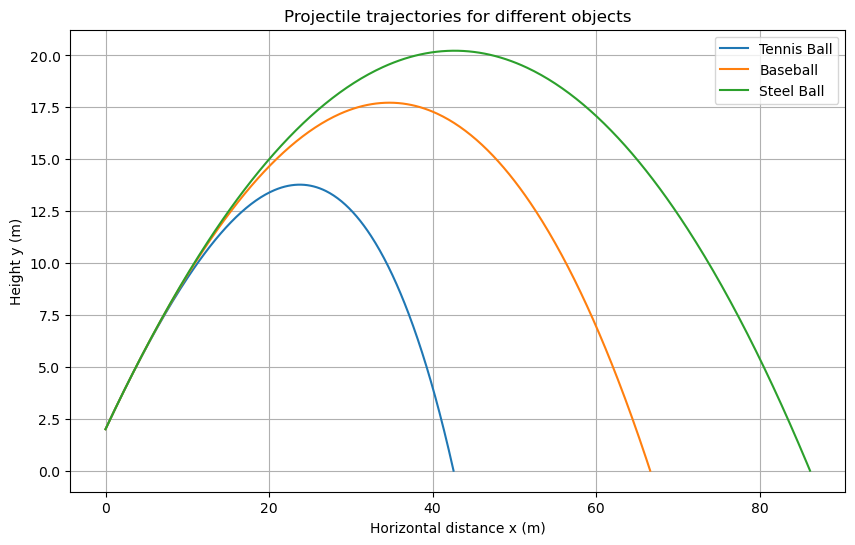

In [6]:
plt.figure(figsize=(10, 6))

for item in object_results:
    result = item["result"]
    name = item["config"]["name"]

    plot_t, plot_y = trajectory_with_landing_point(result)

    plt.plot(
        plot_y[:, 0],
        plot_y[:, 1],
        label=name
    )

plt.title("Projectile trajectories for different objects")
plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.legend()
plt.grid(True)
plt.show()

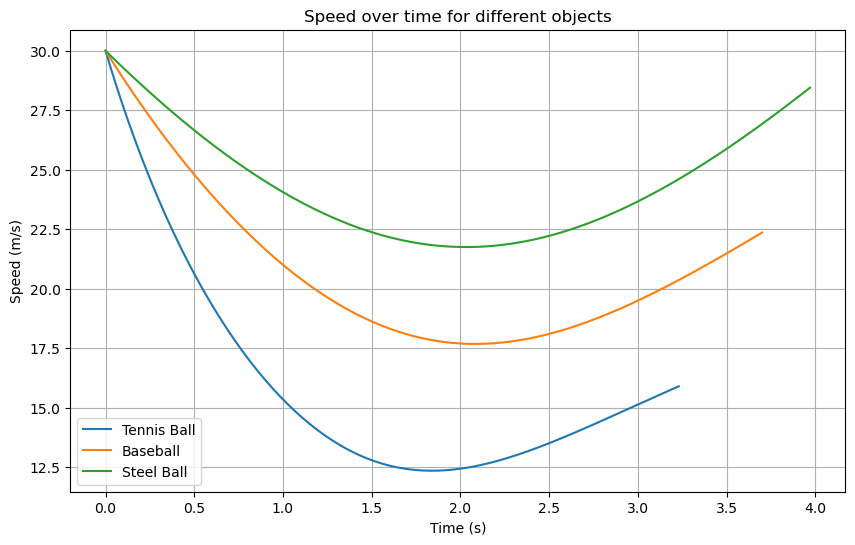

In [7]:
plt.figure(figsize=(10, 6))

for item in object_results:
    result = item["result"]
    name = item["config"]["name"]

    vx = result["y"][:, 2]
    vy = result["y"][:, 3]
    speed = np.sqrt(vx ** 2 + vy ** 2)

    plt.plot(
        result["t"],
        speed,
        label=name
    )

plt.title("Speed over time for different objects")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True)
plt.show()

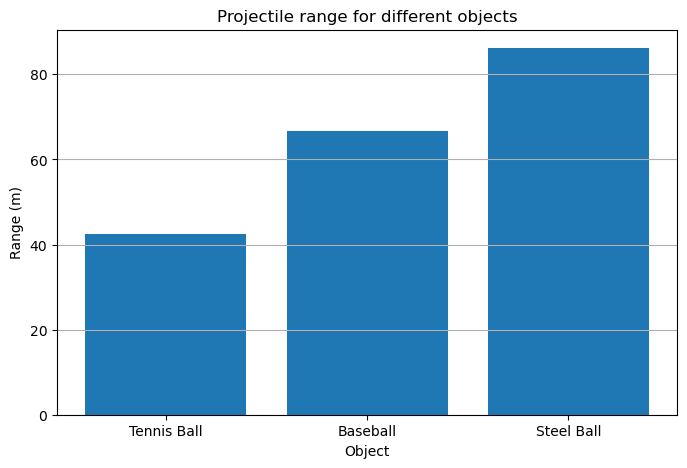

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    object_summary_df["object"],
    object_summary_df["range_m"]
)

plt.title("Projectile range for different objects")
plt.xlabel("Object")
plt.ylabel("Range (m)")
plt.grid(True, axis="y")
plt.show()

### Object comparison observations

The object comparison shows that projectile motion with air resistance depends strongly on the physical properties of the object.

All three objects were launched with the same initial speed, launch angle, initial height, gravity, and air density. The only differences were mass, radius, and drag coefficient. These differences affect the drag parameter:

k = (rho * Cd * A) / (2m)

The tennis ball had the largest drag parameter, approximately 0.0208, so it was affected most strongly by air resistance. It had the shortest range, about 42.57 m, and the lowest maximum height, about 13.78 m.

The baseball had a smaller drag parameter, approximately 0.00622. As a result, it traveled farther than the tennis ball, reaching a range of about 66.62 m.

The steel ball had the smallest drag parameter, approximately 0.00113. Because of its larger mass and smaller radius, air resistance had the weakest relative effect on it. It reached the largest range, about 86.17 m, and the highest maximum height, about 20.23 m.

The speed-over-time plot also confirms this behavior. The tennis ball loses speed most quickly, while the steel ball retains much more of its initial speed. Later in the trajectory, the speed increases again as the objects fall downward under gravity.

Overall, this section shows that quadratic air resistance does not affect all projectiles equally. The same launch conditions can produce very different trajectories depending on the object's mass, size, and drag coefficient.

## Numerical method comparison

The previous section used RK4 to compare the physical behavior of different objects.

In this section, the object is fixed to the tennis ball, and different numerical methods are compared:

- Euler
- RK2
- RK4

The goal is to analyze how the choice of numerical algorithm and step size affects the simulated trajectory.

A fine-step RK4 solution is used as a numerical reference solution.

In [9]:
REFERENCE_OBJECT = "tennis_ball"

reference_config, reference_result = simulate_object(
    REFERENCE_OBJECT,
    rk4_solver,
    REFERENCE_STEP # h = 0.001
)

reference_summary = summarize_trajectory(reference_result)

reference_config, reference_summary

({'name': 'Tennis Ball',
  'mass': 0.057,
  'radius': 0.0335,
  'drag_coefficient': 0.55,
  'area': 0.003525652355491146,
  'k': 0.020836914688703155},
 {'range': 42.567687573759386,
  'max_height': 13.776997423317885,
  'flight_time': 3.2237314280697413,
  'final_speed': 15.879326800012768})

In [10]:
def simulate_method_for_object(object_key, solver_name, step_size):
    """
    Simulate one object using a chosen solver and step size.
    """
    solver_function = SOLVERS[solver_name]

    obj_config, result = simulate_object(
        object_key,
        solver_function,
        step_size
    )

    summary = summarize_trajectory(result)

    return obj_config, result, summary

In [11]:
def interpolate_reference_to_result(reference_result, result):
    """
    Interpolate reference trajectory onto the time grid of another result.

    To calculate trajectory error, we need to compare the tested solution and the reference solution at the same time values.
    But they use different step sizes, the reference has many more time points (h = 0.001)
    So before comparing them, the notebook interpolates the reference trajectory onto the tested result's time grid.
    """
    t_result = result["t"] # gets the time values from the tested result
    t_ref = reference_result["t"]
    y_ref = reference_result["y"] # gets the reference state values

    interpolated = np.zeros((len(t_result), y_ref.shape[1])) # creates an empty array it has; same number of rows as tested result times,
                                                             # same number of columns as reference state

    for i in range(y_ref.shape[1]): # loops over each state column.
        interpolated[:, i] = np.interp(t_result, t_ref, y_ref[:, i]) # interpolates the reference values at the tested time points

    return interpolated # returns the reference trajectory on the same time grid as the tested trajectory

In [12]:
def mean_squared_error(reference, approximation):
    """
    Calculate the mean squared error between two arrays.

    The arrays should have the same shape.
    """
    reference = np.array(reference, dtype=float)
    approximation = np.array(approximation, dtype=float)

    return np.mean((reference - approximation) ** 2)

In [13]:
STEP_SIZES = [0.1, 0.05, 0.02, 0.01]

method_results = []
method_summaries = []

for solver_name in SOLVERS.keys(): # this creates every method-stepsize combination
    for step_size in STEP_SIZES:
        obj_config, result, summary = simulate_method_for_object(
            REFERENCE_OBJECT,
            solver_name,
            step_size
        )                          # this runs one simulation

        reference_on_result_grid = interpolate_reference_to_result( # puts the reference trajectory on the same time grid.
            reference_result,
            result
        )

        mse = mean_squared_error(
            reference_on_result_grid[:, :2], # means only columns 0 and 1: x and y
            result["y"][:, :2]               # so MSE compares the trajectory position, not velocity
        )

        range_error = abs(reference_summary["range"] - summary["range"])      # compares the landing distance
        relative_range_error = range_error / abs(reference_summary["range"])

        max_height_error = abs(reference_summary["max_height"] - summary["max_height"])  # compares the peak height
        relative_max_height_error = max_height_error / abs(reference_summary["max_height"])

        flight_time_error = abs(reference_summary["flight_time"] - summary["flight_time"]) # compares the landing time
        relative_flight_time_error = flight_time_error / abs(reference_summary["flight_time"])

        method_results.append({ # stores full trajectory data for plotting
            "solver": solver_name,
            "step_size": step_size,
            "result": result,
            "summary": summary,
        })

        method_summaries.append({ # stores table values
            "solver": solver_name,
            "step_size": step_size,
            "n_steps": result["n_steps"],
            "n_function_evals": result["n_function_evals"],

            "range_m": summary["range"],
            "max_height_m": summary["max_height"],
            "flight_time_s": summary["flight_time"],

            "range_error_m": range_error,
            "relative_range_error": relative_range_error,

            "max_height_error_m": max_height_error,
            "relative_max_height_error": relative_max_height_error,

            "flight_time_error_s": flight_time_error,
            "relative_flight_time_error": relative_flight_time_error,

            "mse_position": mse,
        })

method_summary_df = pd.DataFrame(method_summaries)
method_summary_df

,solver,step_size,n_steps,n_function_evals,range_m,max_height_m,flight_time_s,range_error_m,relative_range_error,max_height_error_m,relative_max_height_error,flight_time_error_s,relative_flight_time_error,mse_position
0,Euler,0.10,33,33,42.848281,14.334422,3.260176,0.280593,0.006592,0.557425,0.040461,3.644464e-02,1.130511e-02,0.142803
1,Euler,0.05,65,65,42.717120,14.053307,3.242446,0.149433,0.003510,0.276309,0.020056,1.871477e-02,5.805314e-03,0.034127
2,Euler,0.02,162,162,42.629095,13.886827,3.231299,0.061407,0.001443,0.109829,0.007972,7.567509e-03,2.347438e-03,0.005532
3,Euler,0.01,323,323,42.598729,13.832042,3.227533,0.031042,0.000729,0.055044,0.003995,3.801942e-03,1.179361e-03,0.001369
4,RK2,0.10,33,66,42.575807,13.770858,3.223877,0.008119,0.000191,0.006140,0.000446,1.455614e-04,4.515309e-05,0.021740
5,RK2,0.05,65,130,42.569145,13.775358,3.223731,0.001457,0.000034,0.001640,0.000119,6.119532e-07,1.898276e-07,0.001299
6,RK2,0.02,162,324,42.568021,13.776513,3.223738,0.000333,0.000008,0.000485,0.000035,6.917923e-06,2.145937e-06,0.000199
7,RK2,0.01,323,646,42.567748,13.776917,3.223732,0.000060,0.000001,0.000080,0.000006,1.596426e-07,4.952105e-08,0.000014
8,RK4,0.10,33,132,42.562696,13.776710,3.223393,0.004992,0.000117,0.000288,0.000021,3.385163e-04,1.050076e-04,0.021755
9,RK4,0.05,65,260,42.565948,13.776721,3.223613,0.001739,0.000041,0.000276,0.000020,1.183524e-04,3.671286e-05,0.001298


### Error measures and interpretation

The numerical methods were compared with a reference solution computed using RK4 with a very small step size, h = 0.001. The reference solution is treated as the most accurate approximation.

Range error measures the difference between the computed landing distance and the reference landing distance. Euler has the largest range error, while RK2 and RK4 are much closer to the reference.

Relative range error shows the range error as a proportion of the reference range. This makes the error easier to compare. The results again show that Euler is the least accurate method, while RK2 and RK4 have much smaller relative errors.

Maximum height error measures how accurately each method predicts the highest point of the trajectory. Euler gives the largest height error, while RK2 and RK4 reproduce the peak much more accurately.

Flight time error measures the difference between the computed landing time and the reference landing time. Euler has the largest error, while RK2 and RK4 predict the landing time much more accurately.

Mean squared position error measures the average difference between the full computed trajectory and the reference trajectory. Euler has the largest MSE, meaning its trajectory deviates most from the reference. RK2 and RK4 have much smaller MSE values.

Overall, the errors decrease as the step size becomes smaller. This confirms the expected convergence behavior of the numerical methods. Euler is the simplest but least accurate method, while RK2 and RK4 give much more accurate projectile simulations.

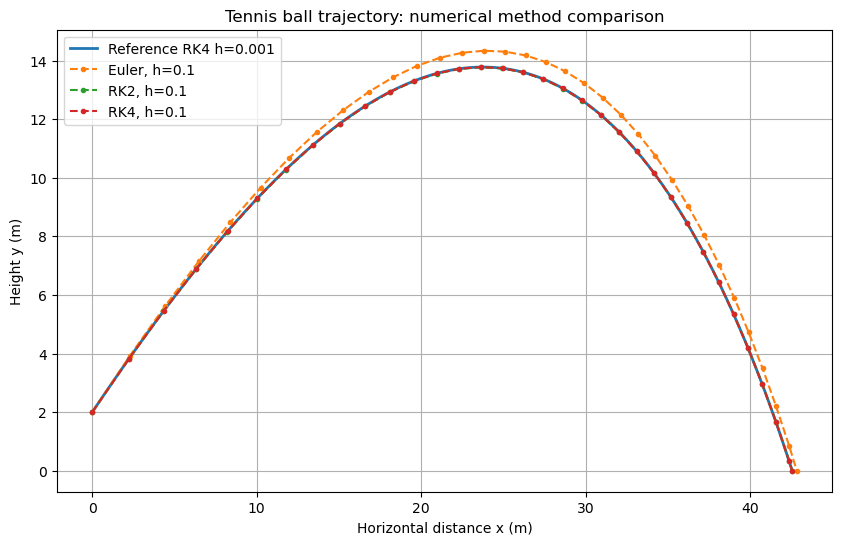

In [14]:
# This plot visually compares Euler, RK2, RK4, and the reference trajectory for step size h = 0.1 (the biggest one)

SELECTED_STEP = 0.1

plt.figure(figsize=(10, 6))

ref_t_plot, ref_y_plot = trajectory_with_landing_point(reference_result)

plt.plot(
    ref_y_plot[:, 0],
    ref_y_plot[:, 1],
    label=f"Reference RK4 h={REFERENCE_STEP}",
    linewidth=2
)

selected_results = [
    item for item in method_results
    if item["step_size"] == SELECTED_STEP
]

for item in selected_results:
    result = item["result"]
    solver = item["solver"]

    plot_t, plot_y = trajectory_with_landing_point(result)

    plt.plot(
        plot_y[:, 0],
        plot_y[:, 1],
        marker="o",
        markersize=3,
        linestyle="--",
        label=f"{solver}, h={SELECTED_STEP}"
    )

plt.title("Tennis ball trajectory: numerical method comparison")
plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
error_summary_df = method_summary_df[
    [
        "solver",
        "step_size",
        "range_error_m",
        "relative_range_error",
        "max_height_error_m",
        "relative_max_height_error",
        "flight_time_error_s",
        "relative_flight_time_error",
        "mse_position",
    ]
].copy()

error_summary_df

,solver,step_size,range_error_m,relative_range_error,max_height_error_m,relative_max_height_error,flight_time_error_s,relative_flight_time_error,mse_position
0,Euler,0.10,0.280593,0.006592,0.557425,0.040461,3.644464e-02,1.130511e-02,0.142803
1,Euler,0.05,0.149433,0.003510,0.276309,0.020056,1.871477e-02,5.805314e-03,0.034127
2,Euler,0.02,0.061407,0.001443,0.109829,0.007972,7.567509e-03,2.347438e-03,0.005532
3,Euler,0.01,0.031042,0.000729,0.055044,0.003995,3.801942e-03,1.179361e-03,0.001369
4,RK2,0.10,0.008119,0.000191,0.006140,0.000446,1.455614e-04,4.515309e-05,0.021740
5,RK2,0.05,0.001457,0.000034,0.001640,0.000119,6.119532e-07,1.898276e-07,0.001299
6,RK2,0.02,0.000333,0.000008,0.000485,0.000035,6.917923e-06,2.145937e-06,0.000199
7,RK2,0.01,0.000060,0.000001,0.000080,0.000006,1.596426e-07,4.952105e-08,0.000014
8,RK4,0.10,0.004992,0.000117,0.000288,0.000021,3.385163e-04,1.050076e-04,0.021755
9,RK4,0.05,0.001739,0.000041,0.000276,0.000020,1.183524e-04,3.671286e-05,0.001298


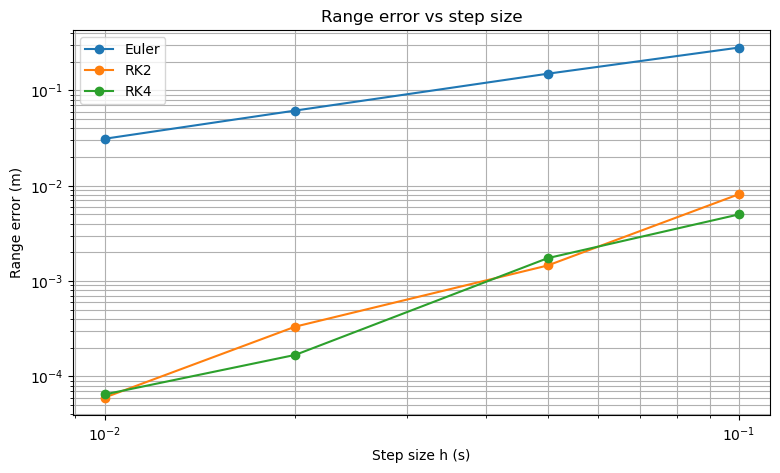

In [16]:
plt.figure(figsize=(9, 5))

for solver_name in SOLVERS.keys():
    solver_df = method_summary_df[method_summary_df["solver"] == solver_name]

    plt.plot(
        solver_df["step_size"],
        solver_df["range_error_m"],
        marker="o",
        label=solver_name
    )

plt.xscale("log") # a log scale makes it easier to see all methods on one plot
plt.yscale("log")
plt.title("Range error vs step size")
plt.xlabel("Step size h (s)")
plt.ylabel("Range error (m)")
plt.legend()
plt.grid(True, which="both")
plt.show()

RK2 and h = 0.05 actually produced a smaller error than rk4. The difference is tiny: about 0.000282 m, less than a millimeter. So this is not meaningful enough to say RK2 is “better overall.” It just means that for this specific output, at this specific step size, RK2 happened to be slightly closer.

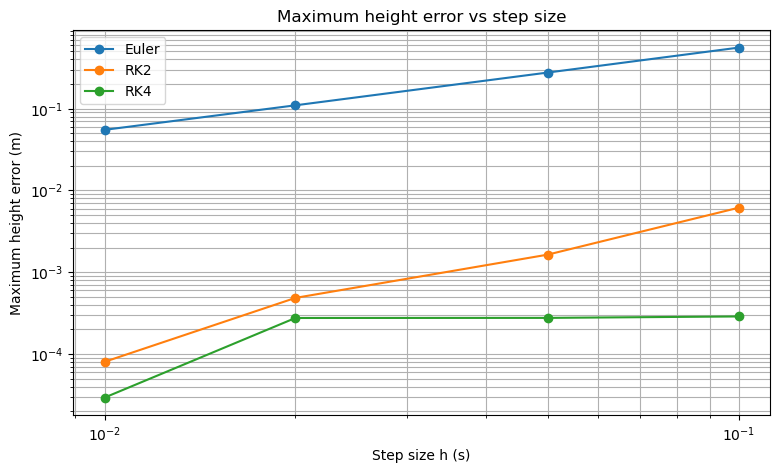

In [17]:
plt.figure(figsize=(9, 5))

for solver_name in SOLVERS.keys():
    solver_df = method_summary_df[method_summary_df["solver"] == solver_name]

    plt.plot(
        solver_df["step_size"],
        solver_df["max_height_error_m"],
        marker="o",
        label=solver_name
    )

plt.xscale("log")
plt.yscale("log")
plt.title("Maximum height error vs step size")
plt.xlabel("Step size h (s)")
plt.ylabel("Maximum height error (m)")
plt.legend()
plt.grid(True, which="both")
plt.show()

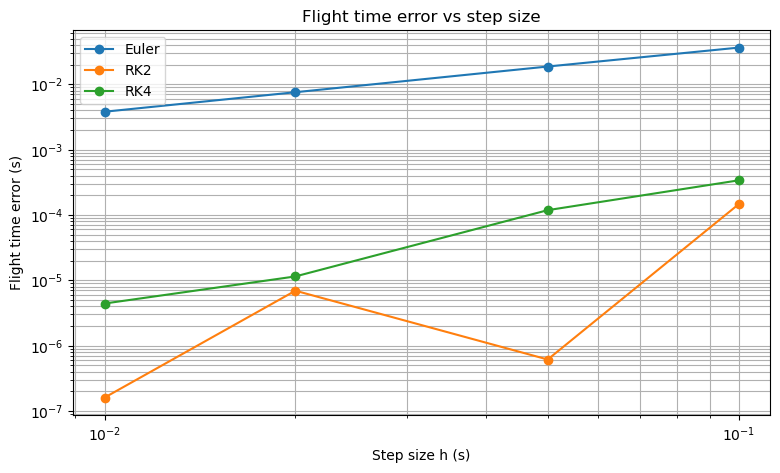

In [18]:
plt.figure(figsize=(9, 5))

for solver_name in SOLVERS.keys():
    solver_df = method_summary_df[method_summary_df["solver"] == solver_name]

    plt.plot(
        solver_df["step_size"],
        solver_df["flight_time_error_s"],
        marker="o",
        label=solver_name
    )

plt.xscale("log")
plt.yscale("log")
plt.title("Flight time error vs step size")
plt.xlabel("Step size h (s)")
plt.ylabel("Flight time error (s)")
plt.legend()
plt.grid(True, which="both")
plt.show()

Flight time is not directly solved by the ODE. It is estimated from the moment where the trajectory crosses y=0. The solver takes steps, then the code uses landing interpolation between the last point above ground and the first point below ground.

So flight time depends heavily on:

-the final step

-the ground-crossing interpolation

-small cancellation effects


RK2 can accidentally land closer to the reference crossing time than RK4 for this setup.

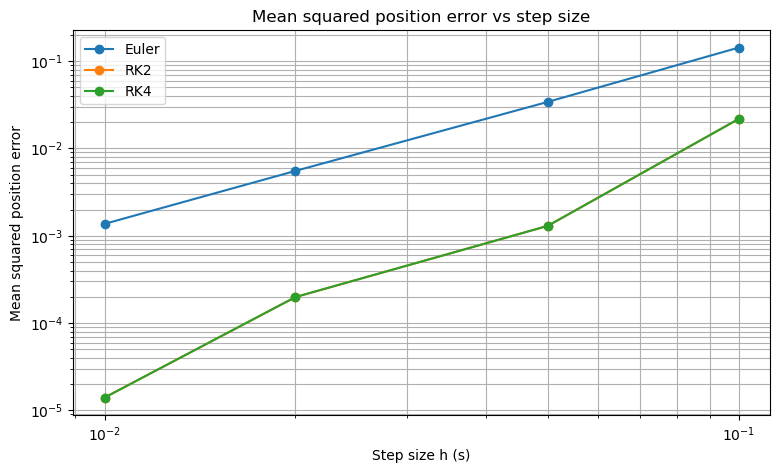

In [19]:
# MSE measures the average difference between two trajectories.

plt.figure(figsize=(9, 5))

for solver_name in SOLVERS.keys():
    solver_df = method_summary_df[method_summary_df["solver"] == solver_name]

    plt.plot(
        solver_df["step_size"],
        solver_df["mse_position"],
        marker="o",
        label=solver_name
    )

plt.xscale("log")
plt.yscale("log")
plt.title("Mean squared position error vs step size")
plt.xlabel("Step size h (s)")
plt.ylabel("Mean squared position error")
plt.legend()
plt.grid(True, which="both")
plt.show()

## Conclusion

This notebook simulated projectile motion with quadratic air resistance using a system of ordinary differential equations.

The object comparison showed that physical properties strongly affect the trajectory. The tennis ball had the largest drag effect and the shortest range, while the steel ball was affected least by air resistance and traveled the farthest.

The numerical method comparison showed that Euler produced the largest errors, especially for larger step sizes. RK2 and RK4 were much closer to the fine-step RK4 reference solution. As the step size decreased, the errors generally decreased, confirming the expected convergence behavior of the numerical methods.

Overall, the project demonstrates how numerical ODE solvers can be used to simulate a physical system where acceleration changes during motion because of velocity-dependent air resistance.